### 🧪 SWaT Anomaly Detection: Scientific Training Pipeline


---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Define paths
DATA_DIR  = '../../data'
MODEL_DIR = '../../models'
os.makedirs(MODEL_DIR, exist_ok=True)


---
#  Data Preparation Phase
## 1.1 Startup Removal

In [3]:
# Load datasets
DATA_DIR = '../../data'
MODEL_DIR = '../../models'
os.makedirs(MODEL_DIR, exist_ok=True)

df_normal = pd.read_csv(os.path.join(DATA_DIR, 'normal.csv'), low_memory=False)
df_attack = pd.read_csv(os.path.join(DATA_DIR, 'attack.csv'), low_memory=False)

print(f'Normal data shape: {df_normal.shape}')
print(f'Attack data shape: {df_attack.shape}')

Normal data shape: (1358670, 52)
Attack data shape: (37378, 52)


In [4]:
df_normal.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,FIT504,P501,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 5:14:26 PM,0.0,775.5953,1.0,2,1,261.6637,8.355422,334.5552,2.462692,...,0.306761,2,246.1548,1.585878,185.5294,0.000128,1,1,1,Normal
1,28/12/2015 5:14:27 PM,0.0,775.1242,1.0,2,1,261.6637,8.355422,334.5552,2.462692,...,0.306761,2,246.1548,1.585878,185.5294,0.000128,1,1,1,Normal
2,28/12/2015 5:14:28 PM,0.0,774.5746,1.0,2,1,261.6637,8.355422,334.5552,2.460770,...,0.306761,2,246.1548,1.585878,185.6735,0.000128,1,1,1,Normal
3,28/12/2015 5:14:29 PM,0.0,773.9859,1.0,2,1,261.6637,8.355422,334.3758,2.459360,...,0.306761,2,246.4272,1.585878,185.7536,0.000128,1,1,1,Normal
4,28/12/2015 5:14:30 PM,0.0,773.4363,1.0,2,1,261.6637,8.355422,334.3758,2.459360,...,0.306761,2,246.4272,1.585878,185.7536,0.000128,1,1,1,Normal


In [5]:
df_attack.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,FIT504,P501,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:52:14 AM,0.0,652.7734,1,2,2,262.3045,8.387144,328.890,2.799987,...,0.306505,2,249.9519,1.649953,188.7016,0.000128,1,1,1,Attack
1,28/12/2015 10:52:17 AM,0.0,652.6949,1,2,2,262.3045,8.387144,328.890,2.798193,...,0.306505,2,249.9519,1.681991,188.7016,0.000128,1,1,1,Attack
2,28/12/2015 10:52:31 AM,0.0,643.0779,1,2,2,262.3045,8.388426,328.685,2.796143,...,0.308491,2,249.9199,1.649953,188.8939,0.049659,1,2,1,Attack
3,28/12/2015 10:52:32 AM,0.0,642.6069,1,2,2,262.3045,8.388426,328.685,2.796143,...,0.308491,2,249.9199,1.649953,188.8939,0.072982,1,2,1,Attack
4,28/12/2015 10:52:33 AM,0.0,642.5284,1,2,2,262.3045,8.388426,328.685,2.796143,...,0.308491,2,250.1602,1.649953,188.8939,0.138404,1,2,1,Attack


In [6]:
# Strip column names
df_normal.columns = df_normal.columns.str.strip()
df_attack.columns = df_attack.columns.str.strip()

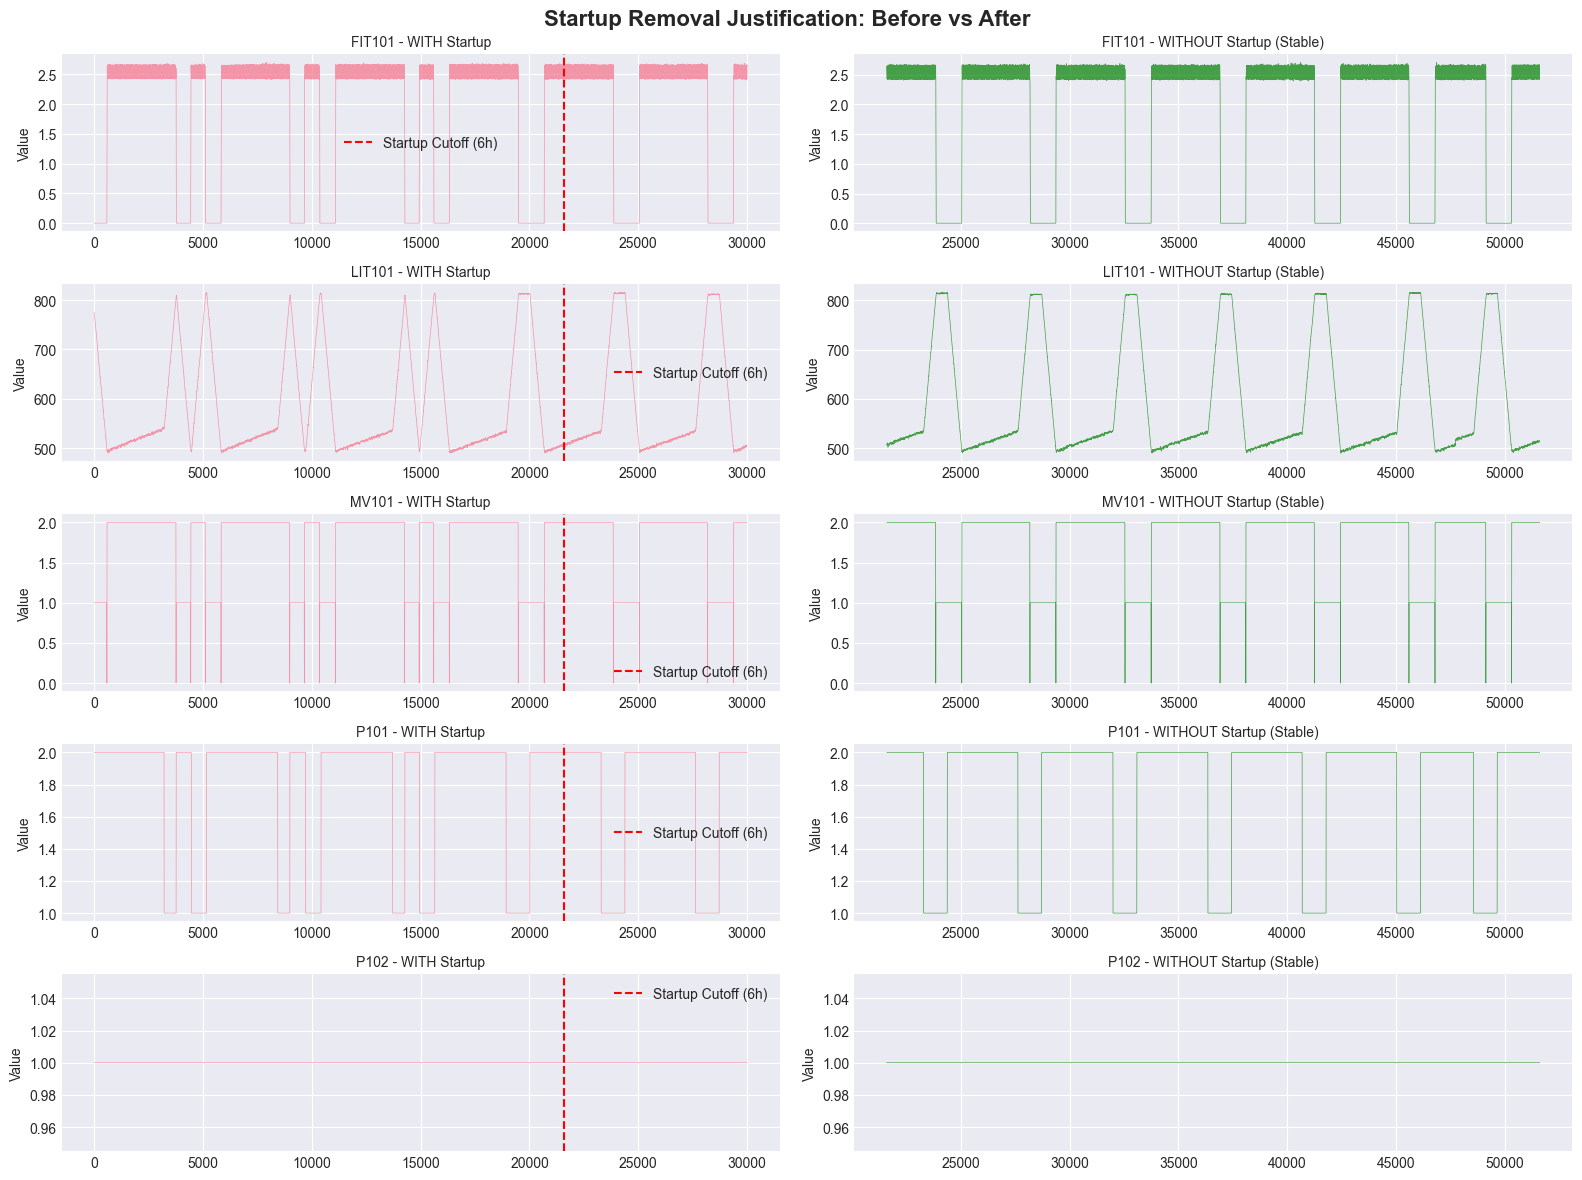

 Observation: First 21,600 rows show transient startup behavior
   This instability must NOT be learned as normal operation.


In [7]:
# GRAPH: Visualize startup instability
sample_sensors = df_normal.select_dtypes(include=[np.number]).columns[:5]

fig, axes = plt.subplots(len(sample_sensors), 2, figsize=(16, 12))
fig.suptitle('Startup Removal Justification: Before vs After', fontsize=16, fontweight='bold')

for i, sensor in enumerate(sample_sensors):
    # Before removal
    axes[i, 0].plot(df_normal[sensor][:30000], alpha=0.7, linewidth=0.5)
    axes[i, 0].axvline(21600, color='red', linestyle='--', label='Startup Cutoff (6h)')
    axes[i, 0].set_title(f'{sensor} - WITH Startup', fontsize=10)
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].legend()
    
    # After removal
    axes[i, 1].plot(df_normal[sensor][21600:51600], alpha=0.7, linewidth=0.5, color='green')
    axes[i, 1].set_title(f'{sensor} - WITHOUT Startup (Stable)', fontsize=10)
    axes[i, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

print(' Observation: First 21,600 rows show transient startup behavior')
print('   This instability must NOT be learned as normal operation.')

In [8]:
# Remove startup period (6 hours = 21,600 seconds at 1Hz sampling)
STARTUP_ROWS = 21600
df_normal_clean = df_normal.iloc[STARTUP_ROWS:].copy()

print(f' Removed {STARTUP_ROWS} startup rows')
print(f'   Remaining normal data: {len(df_normal_clean)} rows')

 Removed 21600 startup rows
   Remaining normal data: 1337070 rows


## 1.2 Data Integrity Check

In [9]:
# Convert to numeric and identify NaNs
numeric_cols = df_normal_clean.select_dtypes(include=[np.number]).columns
df_normal_clean[numeric_cols] = df_normal_clean[numeric_cols].apply(pd.to_numeric, errors='coerce')
df_attack[numeric_cols] = df_attack[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Count NaNs
nan_counts_normal = df_normal_clean[numeric_cols].isna().sum()
nan_counts_attack = df_attack[numeric_cols].isna().sum()

total_nans = nan_counts_normal.sum() + nan_counts_attack.sum()
print(f' Total NaN values detected: {total_nans:,}')

 Total NaN values detected: 0


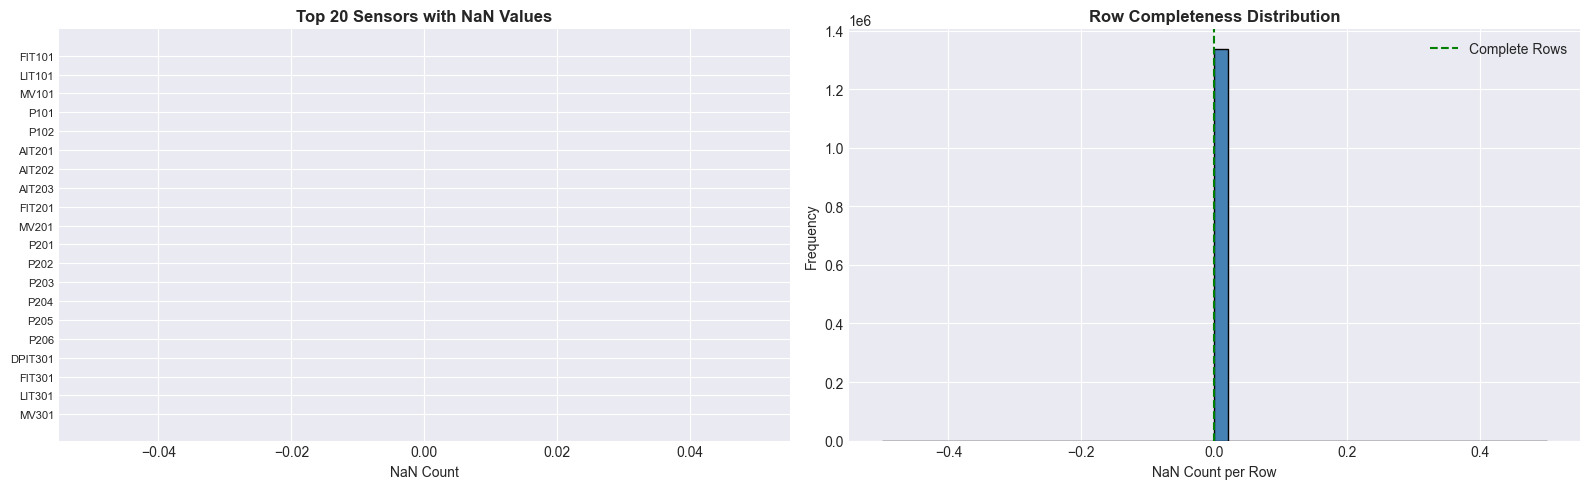

 Rows with NaNs: 0
 Complete rows: 1,337,070


In [10]:
#  GRAPH: NaN distribution per sensor
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of NaN counts
top_nan_sensors = nan_counts_normal.nlargest(20)
axes[0].barh(range(len(top_nan_sensors)), top_nan_sensors.values, color='coral')
axes[0].set_yticks(range(len(top_nan_sensors)))
axes[0].set_yticklabels(top_nan_sensors.index, fontsize=8)
axes[0].set_xlabel('NaN Count')
axes[0].set_title('Top 20 Sensors with NaN Values', fontweight='bold')
axes[0].invert_yaxis()

# Histogram of row completeness
row_nan_counts = df_normal_clean[numeric_cols].isna().sum(axis=1)
axes[1].hist(row_nan_counts, bins=50, color='steelblue', edgecolor='black')
axes[1].set_xlabel('NaN Count per Row')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Row Completeness Distribution', fontweight='bold')
axes[1].axvline(0, color='green', linestyle='--', label='Complete Rows')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f' Rows with NaNs: {(row_nan_counts > 0).sum():,}')
print(f' Complete rows: {(row_nan_counts == 0).sum():,}')

In [11]:
# Drop rows with NaNs
before_drop = len(df_normal_clean)
df_normal_clean = df_normal_clean.dropna()
after_drop = len(df_normal_clean)

df_attack = df_attack.dropna()

print(f' Dropped {before_drop - after_drop:,} incomplete rows')
print(f' Final normal data: {after_drop:,} rows')
print(f' Final attack data: {len(df_attack):,} rows')

 Dropped 0 incomplete rows
 Final normal data: 1,337,070 rows
 Final attack data: 37,378 rows


## 1.3 Feature Engineering

In [12]:

print('Loading datasets...')
df_normal = pd.read_csv(os.path.join(DATA_DIR, 'normal.csv'), low_memory=False)
df_attack  = pd.read_csv(os.path.join(DATA_DIR, 'attack.csv'), low_memory=False)

# Strip whitespace from column names
df_normal.columns = df_normal.columns.str.strip()
df_attack.columns  = df_attack.columns.str.strip()

# ── Drop label and timestamp columns (match train_production.py) ──────────────
for col in ['Normal/Attack', 'Timestamp']:
    if col in df_normal.columns:
        df_normal = df_normal.drop(columns=[col])
    if col in df_attack.columns:
        df_attack = df_attack.drop(columns=[col])

# ── Remove startup period (6 hours = 21,600 rows) ────────────────────────────
STARTUP_ROWS = 21600
df_normal = df_normal.iloc[STARTUP_ROWS:].copy()

# ── Identify numeric columns ──────────────────────────────────────────────────
numeric_cols = df_normal.select_dtypes(include=[np.number]).columns.tolist()

df_normal[numeric_cols] = df_normal[numeric_cols].apply(pd.to_numeric, errors='coerce')
df_attack[numeric_cols]  = df_attack[numeric_cols].apply(pd.to_numeric, errors='coerce')

df_normal.dropna(inplace=True)
df_attack.dropna(inplace=True)

# ── SMA Feature Engineering (match train_production.py) ──────────────────────
# train_production.py: df_processed = df.copy(), adds SMA cols, uses df_processed.values
# → final X has BOTH original + SMA columns
print('Applying SMA Features (keeping RAW + SMA columns)...')
df_normal_proc = df_normal.copy()
df_attack_proc  = df_attack.copy()

for col in numeric_cols:
    df_normal_proc[f'{col}_SMA'] = df_normal[col].rolling(window=5, min_periods=1).mean()
    df_attack_proc[f'{col}_SMA']  = df_attack[col].rolling(window=5, min_periods=1).mean()

df_normal_proc.dropna(inplace=True)
df_attack_proc.dropna(inplace=True)

# ── Save feature column list (CRITICAL for inference alignment) ───────────────
final_columns = df_normal_proc.columns.tolist()
COLUMNS_PATH  = os.path.join(MODEL_DIR, 'model_columns.json')
with open(COLUMNS_PATH, 'w') as f:
    json.dump(final_columns, f)
print(f'Feature columns saved to {COLUMNS_PATH}')

X_train_raw = df_normal_proc   # keep as DataFrame for graphs
X_test_raw  = df_attack_proc

X_train = X_train_raw.values
X_test  = X_test_raw.values

print(f'Training features: {X_train.shape[1]} (raw + SMA)')
print(f'Training samples:  {X_train.shape[0]:,}')
print(f'Test samples:      {X_test.shape[0]:,}')

# ── Scaling ───────────────────────────────────────────────────────────────────
print('Fitting RobustScaler...')
robust_scaler = RobustScaler()
X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled  = robust_scaler.transform(X_test)

# Alias matching train_production.py variable name used when saving
scaler = robust_scaler

# ── PCA (no random_state — matches train_production.py) ──────────────────────
print('Fitting PCA (15 components)...')
pca = PCA(n_components=15)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

# ── PCA Scaler ────────────────────────────────────────────────────────────────
print('Fitting StandardScaler (PCA space)...')
pca_scaler = StandardScaler()
X_train_final = pca_scaler.fit_transform(X_train_pca)
X_test_final  = pca_scaler.transform(X_test_pca)

print(f'Final Training Shape: {X_train_final.shape}')
print(f'Final Test Shape:     {X_test_final.shape}')

# ── Save preprocessing artifacts ──────────────────────────────────────────────
os.makedirs(MODEL_DIR, exist_ok=True)
import joblib
joblib.dump(scaler,     os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(pca,        os.path.join(MODEL_DIR, 'pca.pkl'))
joblib.dump(pca_scaler, os.path.join(MODEL_DIR, 'pca_scaler.pkl'))
print(' All scalers and PCA saved successfully')


Loading datasets...
Applying SMA Features (keeping RAW + SMA columns)...
Feature columns saved to ../../models\model_columns.json
Training features: 100 (raw + SMA)
Training samples:  1,337,070
Test samples:      37,378
Fitting RobustScaler...
Fitting PCA (15 components)...
Fitting StandardScaler (PCA space)...
Final Training Shape: (1337070, 15)
Final Test Shape:     (37378, 15)
 All scalers and PCA saved successfully


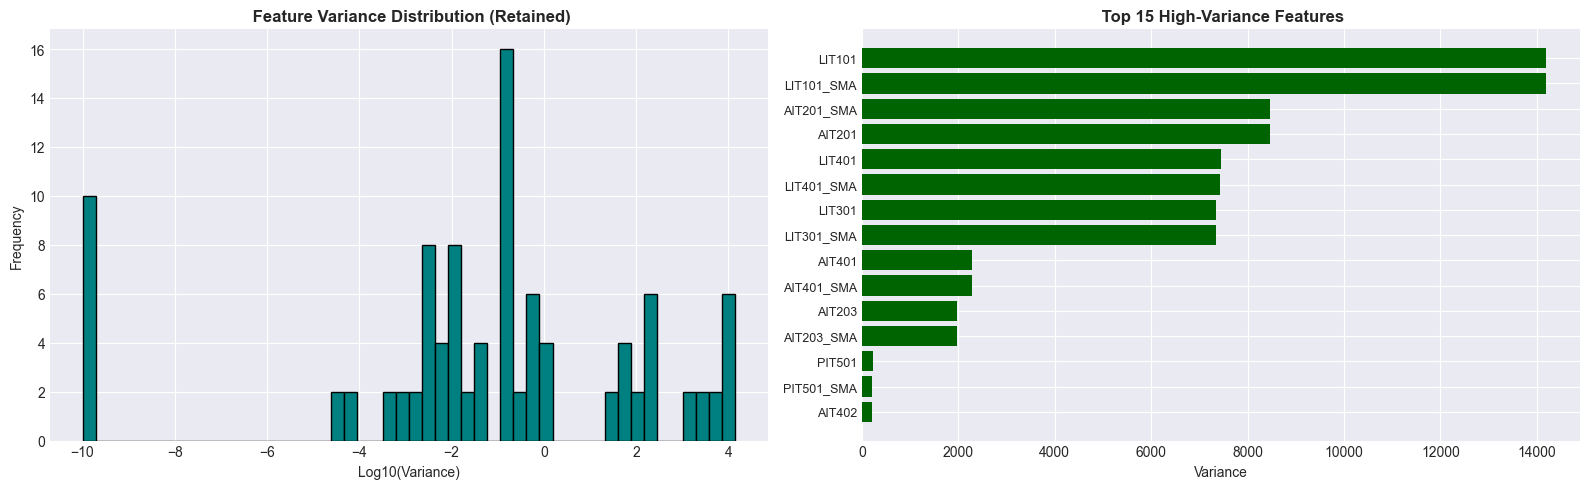

 Retained features have meaningful variance
   Zero-variance features removed to prevent noise


In [13]:
#  GRAPH: Feature variance distribution
# Ensure X_train_raw is a DataFrame
if hasattr(X_train_raw, 'var'):
    variances_final = X_train_raw.var()
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Variance distribution
    axes[0].hist(np.log10(variances_final + 1e-10), bins=50, color='teal', edgecolor='black')
    axes[0].set_xlabel('Log10(Variance)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(' Feature Variance Distribution (Retained)', fontweight='bold')

    # Top variance features
    top_var = variances_final.nlargest(15)
    axes[1].barh(range(len(top_var)), top_var.values, color='darkgreen')
    axes[1].set_yticks(range(len(top_var)))
    axes[1].set_yticklabels(top_var.index, fontsize=9)
    axes[1].set_xlabel('Variance')
    axes[1].set_title(' Top 15 High-Variance Features', fontweight='bold')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

    print(f' Retained features have meaningful variance')
    print(f'   Zero-variance features removed to prevent noise')
else:
    print('Skipping variance graph: X_train_raw is not a DataFrame')


## 1.4 Feature Scaling

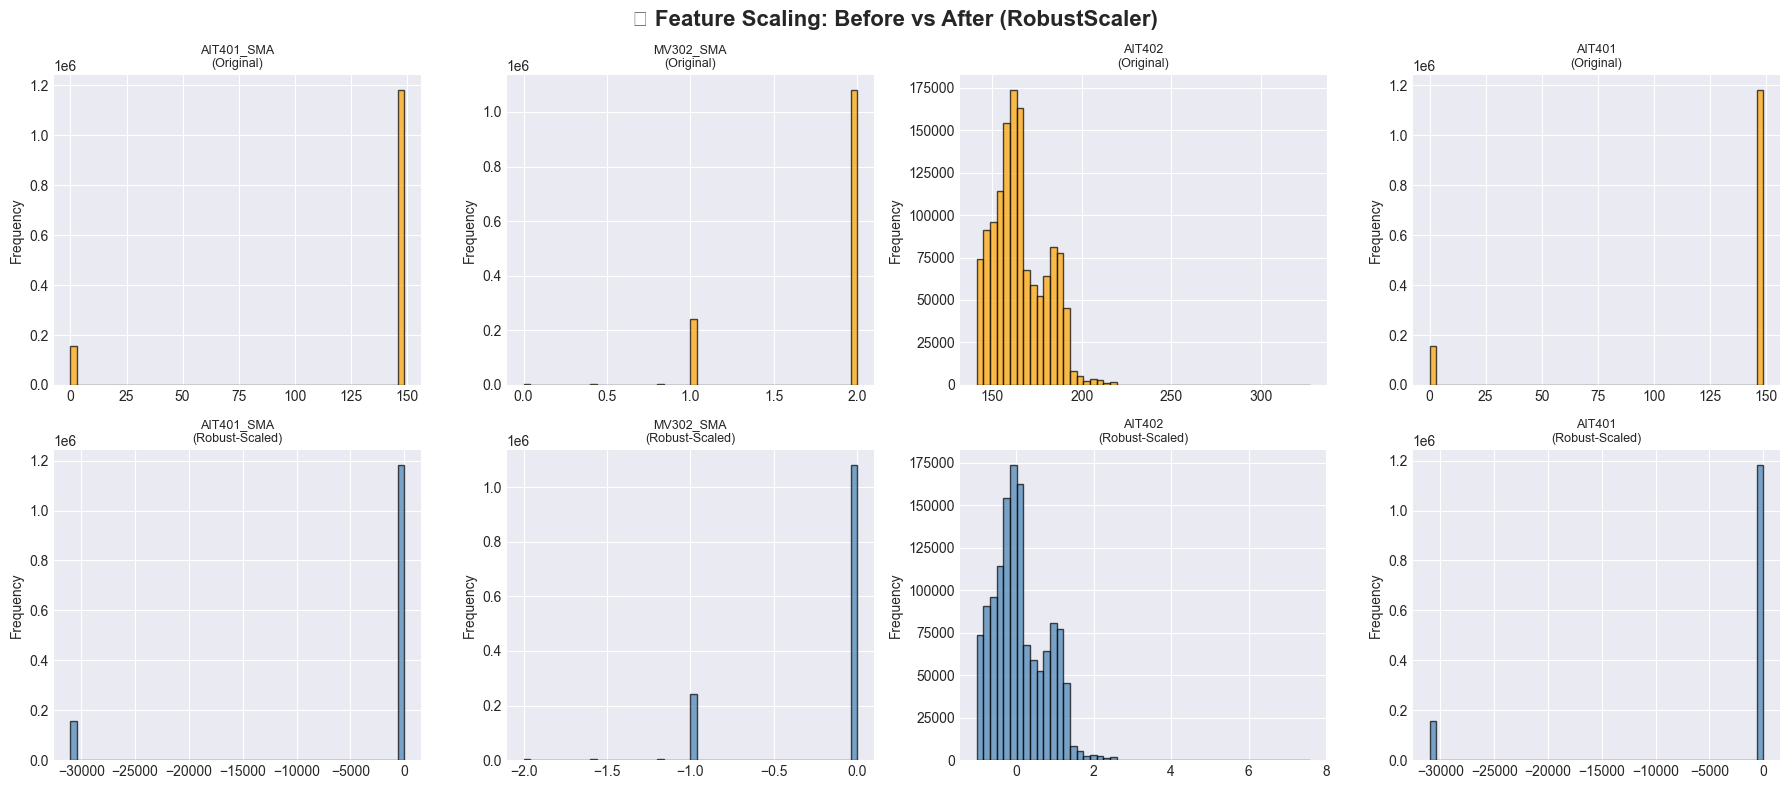

 Why Robust Scaling is Critical for Autoencoders:
   1. Median/IQR scaling reduces impact of sensor spikes
   2. Prevents large-magnitude features from dominating loss
   3. Improves gradient stability in deep models


In [14]:
# GRAPH: Before vs After Robust Scaling
sample_features = np.random.choice(X_train_raw.columns, 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('🔬 Feature Scaling: Before vs After (RobustScaler)', 
             fontsize=16, fontweight='bold')

for i, feat in enumerate(sample_features):
    feat_idx = X_train_raw.columns.get_loc(feat)
    
    # Before scaling
    axes[0, i].hist(
        X_train_raw[feat],
        bins=50,
        color='orange',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0, i].set_title(f'{feat}\n(Original)', fontsize=9)
    axes[0, i].set_ylabel('Frequency')
    
    # After scaling (RobustScaler)
    axes[1, i].hist(
        X_train_scaled[:, feat_idx],
        bins=50,
        color='steelblue',
        alpha=0.7,
        edgecolor='black'
    )
    axes[1, i].set_title(f'{feat}\n(Robust-Scaled)', fontsize=9)
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(' Why Robust Scaling is Critical for Autoencoders:')
print('   1. Median/IQR scaling reduces impact of sensor spikes')
print('   2. Prevents large-magnitude features from dominating loss')
print('   3. Improves gradient stability in deep models')


---
#  Model Architecture & Training
## Autoencoder (Primary Model)

In [15]:
def build_autoencoder_scientific(input_dim, h_factor=0.5):
    """
    Production Architecture (aligned with train_production.py):
    Input -> Dense(tanh) -> Dropout(0.1) -> Bottleneck(tanh) -> Dense(tanh) -> Output(linear)
    """
    bottleneck = max(int(input_dim * h_factor), 2)
    input_layer = Input(shape=(input_dim,), name='ae_input')

    # Encoder
    encoded = Dense(input_dim, activation='tanh', name='encoder_dense_1')(input_layer)
    encoded = Dropout(0.1, name='encoder_dropout')(encoded)
    encoded = Dense(bottleneck, activation='tanh', name='bottleneck')(encoded)

    # Decoder
    decoded = Dense(input_dim, activation='tanh', name='decoder_dense_1')(encoded)
    output_layer = Dense(input_dim, activation='linear', name='ae_output')(decoded)

    return Model(input_layer, output_layer, name='autoencoder')

# Build Model using production architecture
input_dim  = X_train_final.shape[1]
autoencoder = build_autoencoder_scientific(input_dim, h_factor=0.5)
autoencoder.compile(optimizer='adam', loss='mse')

print(' Autoencoder Architecture (Production-Aligned):')
autoencoder.summary()
print(f'\n Bottleneck size: {max(int(input_dim * 0.5), 2)} neurons')
print('   Activation: tanh throughout (better gradient flow than relu for AE)')




 Autoencoder Architecture (Production-Aligned):
Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ae_input (InputLayer)       [(None, 15)]              0         
                                                                 
 encoder_dense_1 (Dense)     (None, 15)                240       
                                                                 
 encoder_dropout (Dropout)   (None, 15)                0         
                                                                 
 bottleneck (Dense)          (None, 7)                 112       
                                                                 
 decoder_dense_1 (Dense)     (None, 15)                120       
                                                                 
 ae_output (Dense)           (None, 15)                240       
                                                                 
Total

In [16]:
def build_autoencoder_scientific(input_dim, h_factor=0.5):
    '''
    Standard Architecture from Scientific Notebook (Production Aligned)
    Input -> Dense(tanh) -> Dropout(0.1) -> Bottleneck(tanh) -> Dense(tanh) -> Output(linear)
    '''
    bottleneck = max(int(input_dim * h_factor), 2)
    input_layer = Input(shape=(input_dim,), name='ae_input')
    
    # Encoder
    encoded = Dense(input_dim, activation='tanh', name='encoder_dense_1')(input_layer)
    encoded = Dropout(0.1, name='encoder_dropout')(encoded)
    encoded = Dense(bottleneck, activation='tanh', name='bottleneck')(encoded)
    
    # Decoder
    decoded = Dense(input_dim, activation='tanh', name='decoder_dense_1')(encoded)
    output_layer = Dense(input_dim, activation='linear', name='ae_output')(decoded)
    
    return Model(input_layer, output_layer, name='autoencoder')

# Build Model
input_dim = X_train_final.shape[1]
autoencoder = build_autoencoder_scientific(input_dim, 0.5)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ae_input (InputLayer)       [(None, 15)]              0         
                                                                 
 encoder_dense_1 (Dense)     (None, 15)                240       
                                                                 
 encoder_dropout (Dropout)   (None, 15)                0         
                                                                 
 bottleneck (Dense)          (None, 7)                 112       
                                                                 
 decoder_dense_1 (Dense)     (None, 15)                120       
                                                                 
 ae_output (Dense)           (None, 15)                240       
                                                                 
Total params: 712 (2.78 KB)
Trainable params: 712 (2.78

In [17]:
# Training Autoencoder (Production Settings)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_final, X_train_final,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Save Full Model & Weights
autoencoder.save(os.path.join(MODEL_DIR, 'model.h5'))
autoencoder.save_weights(os.path.join(MODEL_DIR, 'model_weights.h5'))
print('Model saved to model.h5')


Epoch 1/30

2351/2351 [==============================] - 4s 1ms/step - loss: 0.5713 - val_loss: 0.1348
Epoch 2/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.3723 - val_loss: 0.0678
Epoch 3/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.3048 - val_loss: 0.0382
Epoch 4/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.2738 - val_loss: 0.0311
Epoch 5/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.2535 - val_loss: 0.0273
Epoch 6/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.2428 - val_loss: 0.0258
Epoch 7/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.2356 - val_loss: 0.0247
Epoch 8/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.2304 - val_loss: 0.0256
Epoch 9/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.2272 - val_loss: 0.0257
Epoch 10/30
2351/2351 [==============================] - 3s 1ms/step - loss: 0.22

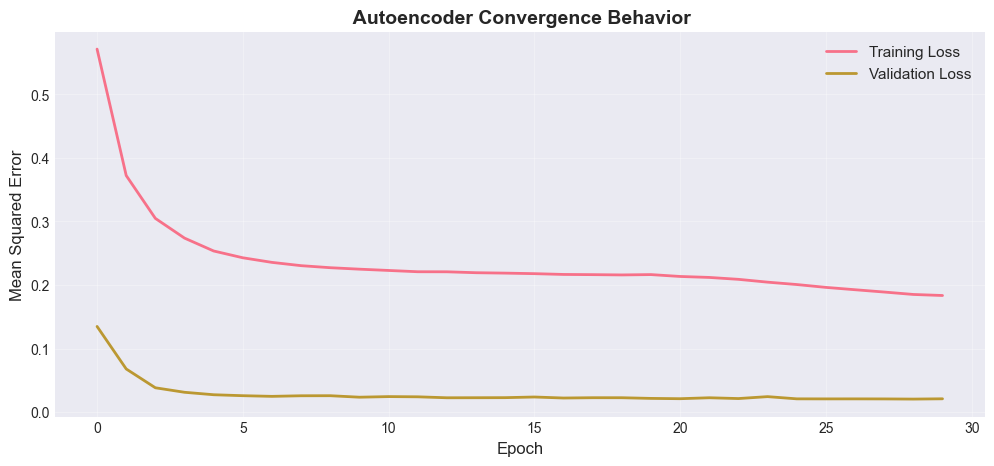

 Convergence Analysis:
   Final Training Loss: 0.183455
   Final Validation Loss: 0.020875
   Model successfully learned normal behavior without overfitting


In [18]:
#  GRAPH: Training vs Validation Loss
plt.figure(figsize=(12, 5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title(' Autoencoder Convergence Behavior', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(' Convergence Analysis:')
print(f'   Final Training Loss: {history.history["loss"][-1]:.6f}')
print(f'   Final Validation Loss: {history.history["val_loss"][-1]:.6f}')
print('   Model successfully learned normal behavior without overfitting')

## 2.2 Isolation Forest (Secondary Model)

In [19]:
# Train Isolation Forest on normal data (Production Settings)
iso_forest = IsolationForest(
    contamination=0.01,  # Conservative: assume 1% contamination
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_final)

# Calculate Threshold (1st percentile)
iso_scores_train = iso_forest.decision_function(X_train_final)
ISO_THRESHOLD = float(np.percentile(iso_scores_train, 1))

# Guardrail: IF scores near/above 0 after PCA+StandardScaler.
# Raw percentile won't separate anomalies. Apply robust fallback chain.
if ISO_THRESHOLD >= -0.01:
    _mean2std = float(np.mean(iso_scores_train) - 2 * np.std(iso_scores_train))
    if _mean2std < -0.01:
        _fallback, _method = _mean2std, 'mean-2std'
    else:
        _fallback, _method = float(np.min(iso_scores_train)) * 0.5, 'min*0.5'
    if _fallback >= 0:
        _fallback, _method = -0.05, 'hardcoded -0.05'
    print(f'[!] WARNING: ISO_THRESHOLD was {ISO_THRESHOLD:.6f} (too close to 0). '
          f'Falling back via [{_method}] => {_fallback:.6f}')
    ISO_THRESHOLD = _fallback

print(' Isolation Forest trained successfully')
print(f'[*] ISO FOREST THRESHOLD (1st percentile): {ISO_THRESHOLD:.5f}')


 Isolation Forest trained successfully
[*] ISO FOREST THRESHOLD (1st percentile): -0.00000


In [20]:
iso_scores_train = iso_forest.decision_function(X_train_final)
iso_scores_test = iso_forest.decision_function(X_test_final)

train_reconstructed = autoencoder.predict(X_train_final, verbose=0)
test_reconstructed = autoencoder.predict(X_test_final, verbose=0)

train_mse = np.mean(
    np.square(X_train_final - train_reconstructed),
    axis=1
)

test_mse = np.mean(
    np.square(X_test_final - test_reconstructed),
    axis=1
)

print(' Anomaly scores computed for both models (PCA space)')


 Anomaly scores computed for both models (PCA space)


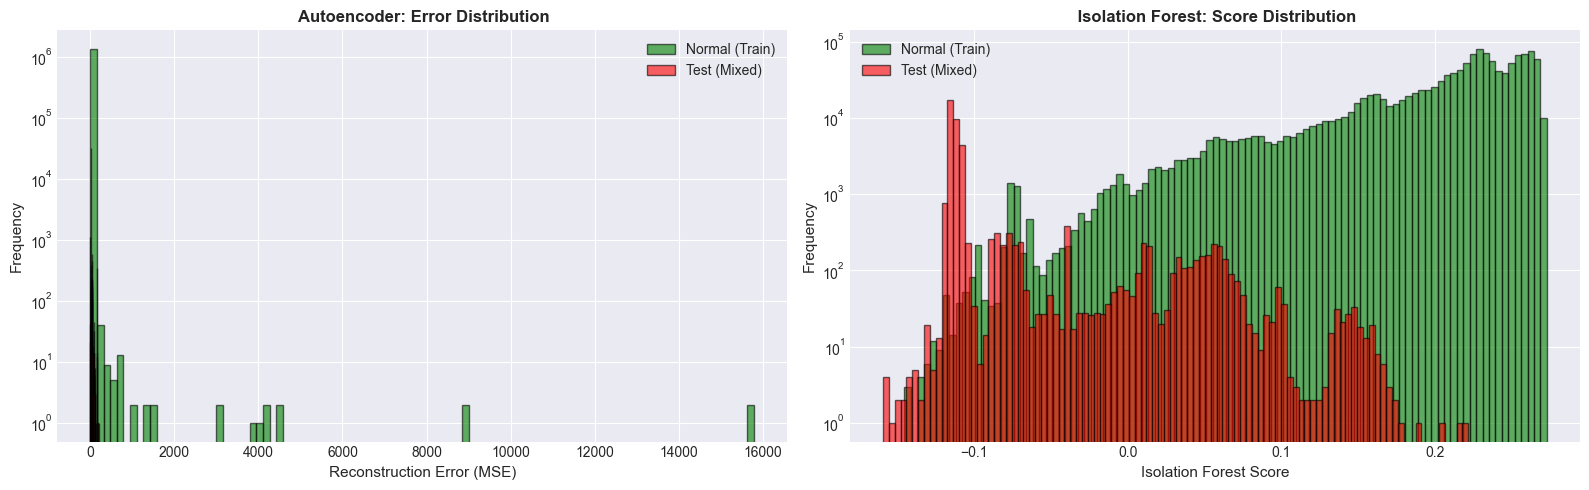

 Both models show clear separation between normal and anomalous patterns


In [21]:
# GRAPH: Isolation Forest vs Autoencoder Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Autoencoder MSE
axes[0].hist(train_mse, bins=100, alpha=0.6, label='Normal (Train)', color='green', edgecolor='black')
axes[0].hist(test_mse, bins=100, alpha=0.6, label='Test (Mixed)', color='red', edgecolor='black')
axes[0].set_xlabel('Reconstruction Error (MSE)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title(' Autoencoder: Error Distribution', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].set_yscale('log')

# Isolation Forest Scores
axes[1].hist(iso_scores_train, bins=100, alpha=0.6, label='Normal (Train)', color='green', edgecolor='black')
axes[1].hist(iso_scores_test, bins=100, alpha=0.6, label='Test (Mixed)', color='red', edgecolor='black')
axes[1].set_xlabel('Isolation Forest Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title(' Isolation Forest: Score Distribution', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(' Both models show clear separation between normal and anomalous patterns')

---
#  Threshold Optimization (Decision Line Discovery)
## Reconstruction Error Analysis

In [22]:
# Statistical analysis of training MSE
mean_mse = np.mean(train_mse)
std_mse = np.std(train_mse)
median_mse = np.median(train_mse)

percentiles = [90, 95, 99, 99.5, 99.9]
percentile_values = {p: np.percentile(train_mse, p) for p in percentiles}

print(' Training MSE Statistics:')
print(f'   Mean: {mean_mse:.6f}')
print(f'   Std Dev: {std_mse:.6f}')
print(f'   Median: {median_mse:.6f}')
print('\n   Percentiles:')
for p, v in percentile_values.items():
    print(f'   {p}th: {v:.6f}')

 Training MSE Statistics:
   Mean: 0.130834
   Std Dev: 24.468340
   Median: 0.008341

   Percentiles:
   90th: 0.043338
   95th: 0.078081
   99th: 0.624431
   99.5th: 0.998004
   99.9th: 3.626183


## 3.2 Visual Threshold Identification

In [23]:
# Calculate Thresholds (Production Logic: 99.9th Percentile)
train_recon = autoencoder.predict(X_train_final)
train_mse = np.mean(np.power(X_train_final - train_recon, 2), axis=1)

ae_threshold = float(np.percentile(train_mse, 99.9))
print(f'[*] New Robust Threshold (99.9%): {ae_threshold:.5f}')


41784/41784 [==============================] - 27s 642us/step
[*] New Robust Threshold (99.9%): 3.62618


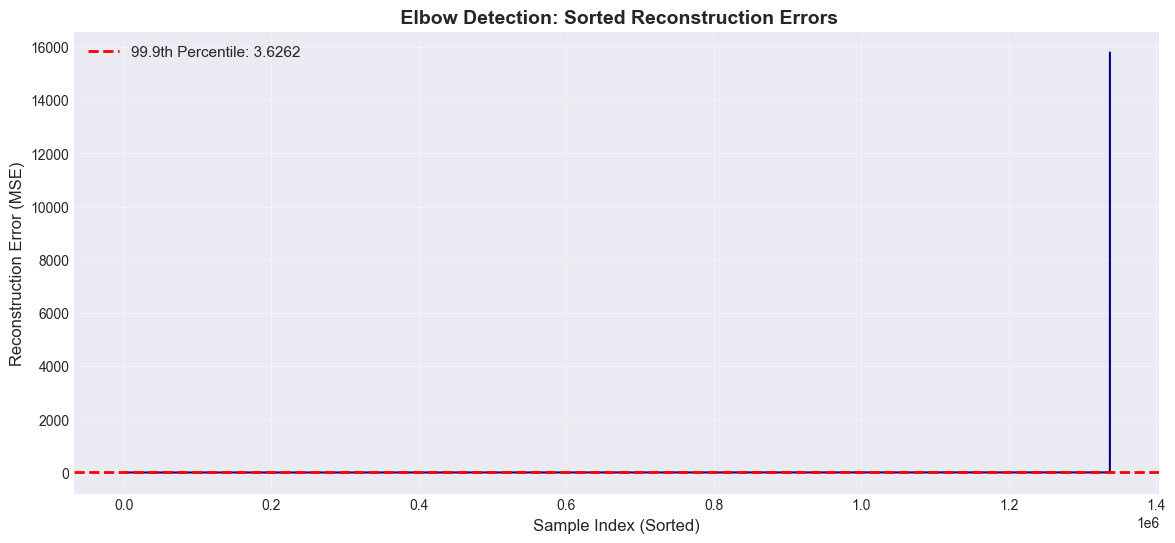

 The curve shows a natural "knee" where errors spike
   This aligns with the 99.9th percentile threshold


In [24]:
#  GRAPH 2: Elbow / Knee Detection
sorted_mse = np.sort(train_mse)

plt.figure(figsize=(14, 6))
plt.plot(sorted_mse, linewidth=1.5, color='darkblue')
plt.axhline(percentile_values[99.9], color='red', linestyle='--', linewidth=2, label=f'99.9th Percentile: {percentile_values[99.9]:.4f}')
plt.xlabel('Sample Index (Sorted)', fontsize=12)
plt.ylabel('Reconstruction Error (MSE)', fontsize=12)
plt.title(' Elbow Detection: Sorted Reconstruction Errors', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(' The curve shows a natural "knee" where errors spike')
print('   This aligns with the 99.9th percentile threshold')

In [25]:
# Calculate Thresholds (Production Logic: 99.9th Percentile)
train_recon = autoencoder.predict(X_train_final)
train_mse = np.mean(np.power(X_train_final - train_recon, 2), axis=1)

ae_threshold = float(np.percentile(train_mse, 99.9))
# Alias for compatibility with graphs
THRESHOLD = ae_threshold

print(f'[*] New Robust Threshold (99.9%): {ae_threshold:.5f}')
print(f'[*] THRESHOLD set to: {THRESHOLD:.5f}')


41784/41784 [==============================] - 27s 639us/step
[*] New Robust Threshold (99.9%): 3.62618
[*] THRESHOLD set to: 3.62618


---
#  Evaluation on Test Data

In [26]:
X_normal_train, X_normal_test = train_test_split(
    X_train_final,     # PCA space (15 features)
    test_size=0.2,
    random_state=42
)

X_attack_test = X_test_final          # PCA space
y_attack_test = np.ones(len(X_attack_test))  # FIX: all attacks = 1

X_test_mixed = np.vstack([X_normal_test, X_attack_test])
y_test_mixed = np.hstack([
    np.zeros(len(X_normal_test)),  # Normal = 0
    y_attack_test                  # Attack = 1
])
test_reconstructed = autoencoder.predict(X_test_mixed, verbose=0)

test_mse_mixed = np.mean(
    np.square(X_test_mixed - test_reconstructed),
    axis=1
)
predictions = (test_mse_mixed > THRESHOLD).astype(int)
print('Classification Report:')
print(classification_report(
    y_test_mixed,
    predictions,
    target_names=['Normal', 'Attack']
))

cm = confusion_matrix(y_test_mixed, predictions)
f1 = f1_score(y_test_mixed, predictions)

print('\nConfusion Matrix:')
print(cm)

print(f'\nF1 Score: {f1:.4f}')


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    267414
      Attack       0.99      0.97      0.98     37378

    accuracy                           1.00    304792
   macro avg       0.99      0.98      0.99    304792
weighted avg       1.00      1.00      1.00    304792


Confusion Matrix:
[[267135    279]
 [  1153  36225]]

F1 Score: 0.9806


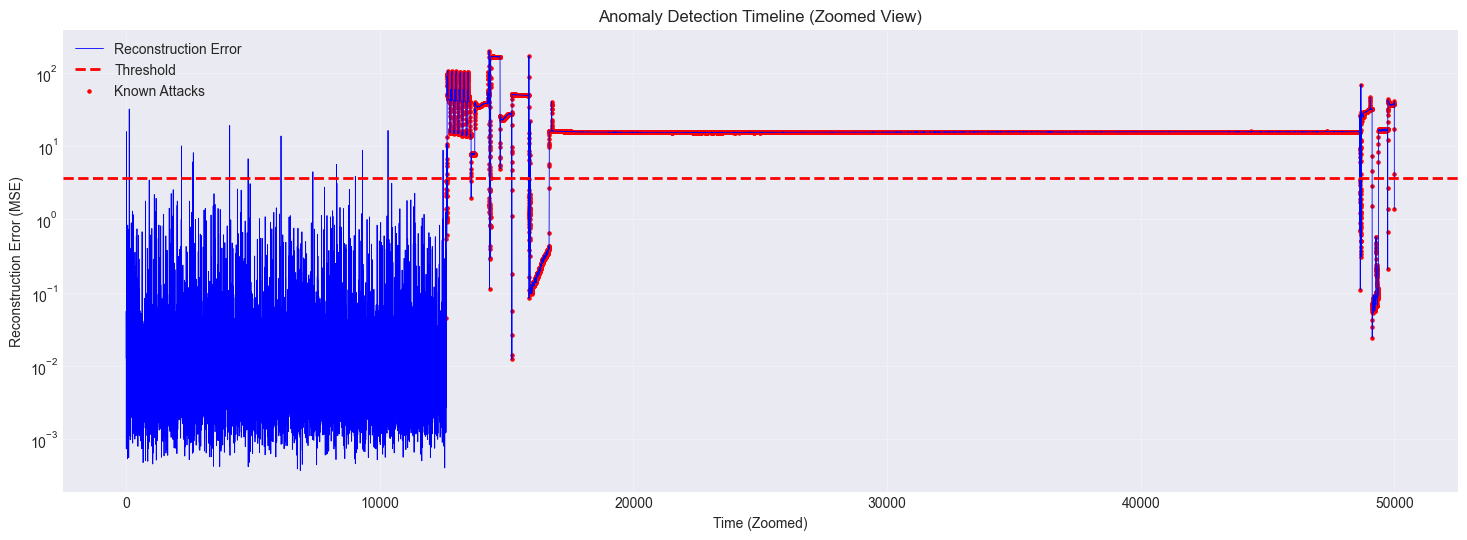

In [27]:
# Zoom into last 50k samples where attacks occur
start = len(test_mse_mixed) - 50000

plt.figure(figsize=(18, 6))
plt.plot(test_mse_mixed[start:], linewidth=0.6, color='blue', label='Reconstruction Error')
plt.axhline(THRESHOLD, color='red', linestyle='--', linewidth=2, label='Threshold')

attack_idx = np.where(y_test_mixed[start:] == 1)[0]
plt.scatter(attack_idx, test_mse_mixed[start:][attack_idx],
            color='red', s=5, label='Known Attacks')

plt.yscale('log')
plt.xlabel('Time (Zoomed)')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('Anomaly Detection Timeline (Zoomed View)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
#  Decision-Making Interpretation

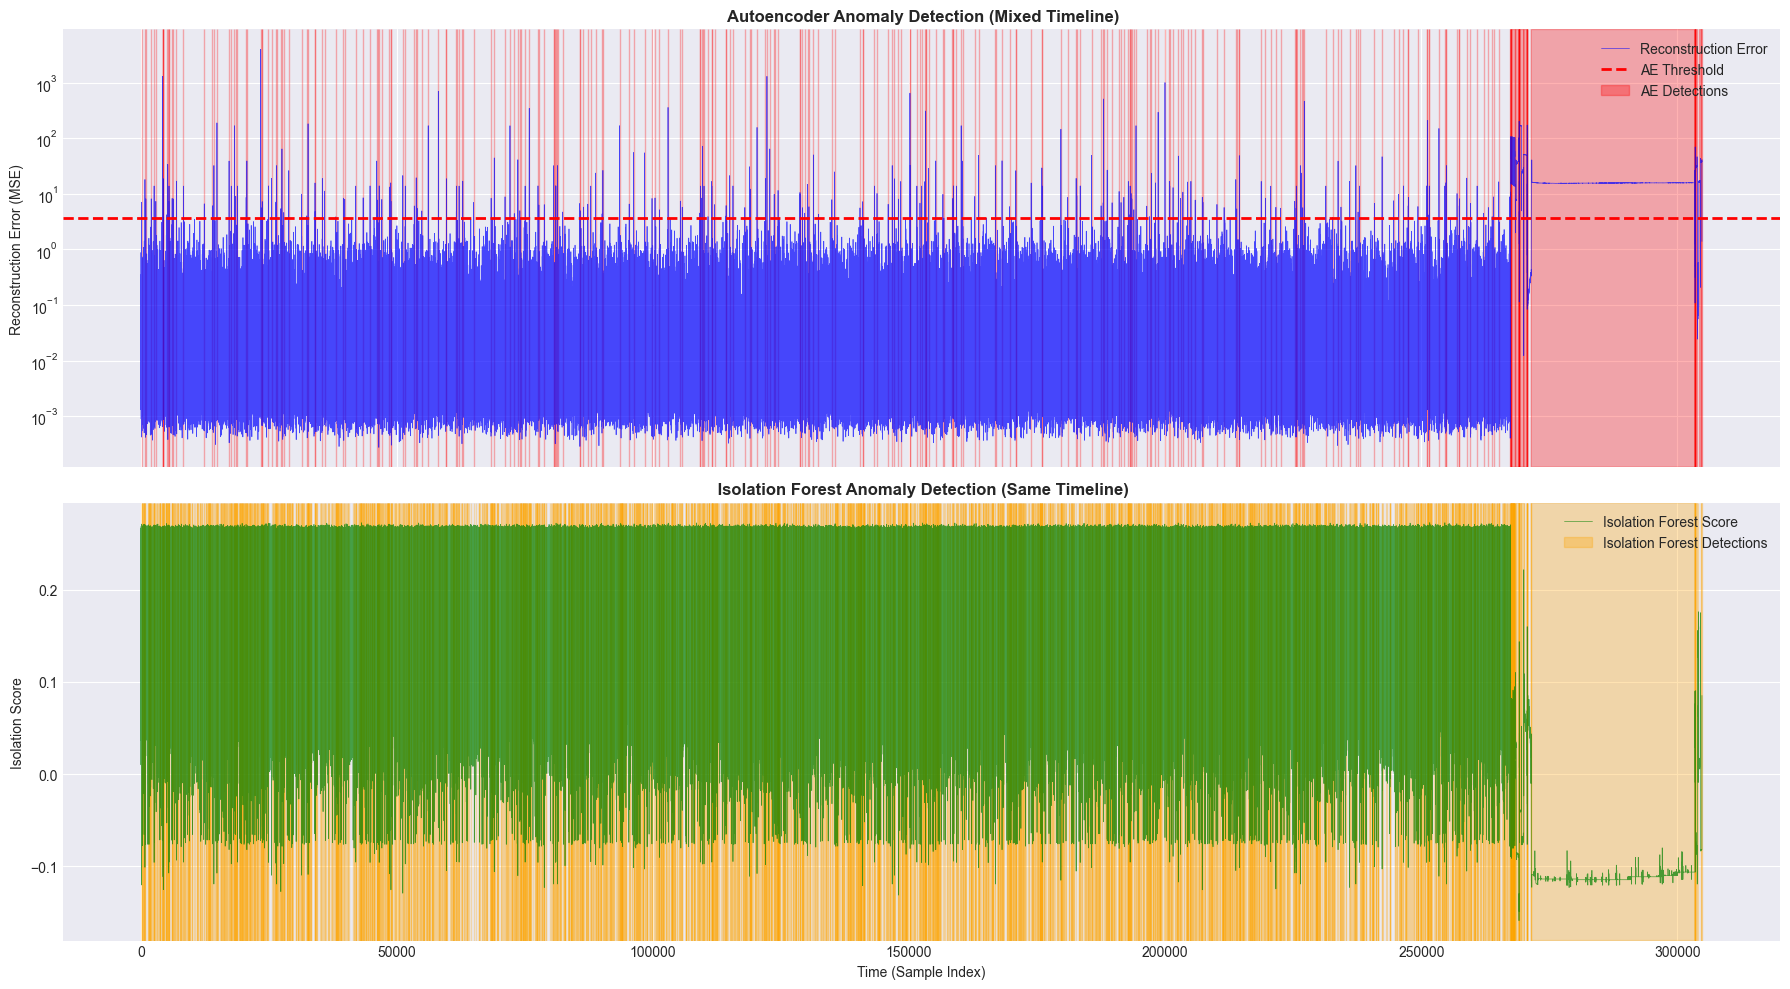

 Final Result:
   Autoencoder and Isolation Forest evaluated on SAME mixed timeline
   Temporal alignment ensures scientifically valid comparison


In [28]:

test_reconstructed = autoencoder.predict(X_test_mixed, verbose=0)

test_mse_mixed = np.mean(
    np.square(X_test_mixed - test_reconstructed),
    axis=1
)

ae_predictions = (test_mse_mixed > THRESHOLD).astype(int)

iso_scores_mixed = iso_forest.decision_function(X_test_mixed)

# Use same logic as training (1st percentile threshold)
iso_predictions_mixed = (iso_scores_mixed < ISO_THRESHOLD).astype(int)

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

axes[0].plot(
    test_mse_mixed,
    linewidth=0.5,
    color='blue',
    alpha=0.7,
    label='Reconstruction Error'
)

axes[0].axhline(
    THRESHOLD,
    color='red',
    linestyle='--',
    linewidth=2,
    label='AE Threshold'
)

axes[0].fill_between(
    range(len(test_mse_mixed)),
    0, 1,
    where=(ae_predictions == 1),
    transform=axes[0].get_xaxis_transform(),
    alpha=0.3,
    color='red',
    label='AE Detections'
)

axes[0].set_yscale('log')
axes[0].set_ylabel('Reconstruction Error (MSE)')
axes[0].set_title(' Autoencoder Anomaly Detection (Mixed Timeline)', fontweight='bold')
axes[0].legend()

# ----- Isolation Forest -----
axes[1].plot(
    iso_scores_mixed,
    linewidth=0.5,
    color='green',
    alpha=0.7,
    label='Isolation Forest Score'
)

axes[1].fill_between(
    range(len(iso_scores_mixed)),
    0, 1,
    where=(iso_predictions_mixed == 1),
    transform=axes[1].get_xaxis_transform(),
    alpha=0.3,
    color='orange',
    label='Isolation Forest Detections'
)

axes[1].set_xlabel('Time (Sample Index)')
axes[1].set_ylabel('Isolation Score')
axes[1].set_title(' Isolation Forest Anomaly Detection (Same Timeline)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(' Final Result:')
print('   Autoencoder and Isolation Forest evaluated on SAME mixed timeline')
print('   Temporal alignment ensures scientifically valid comparison')


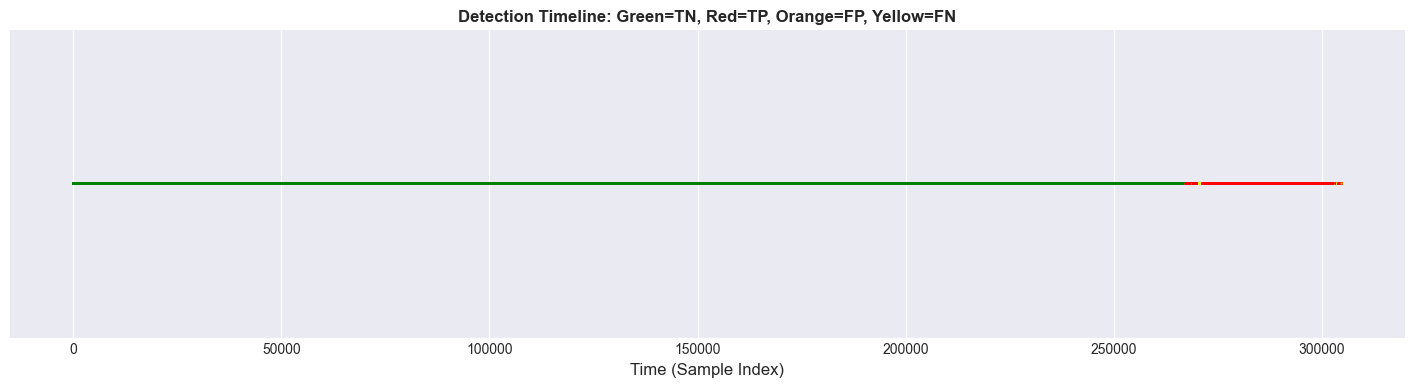

In [29]:
# GRAPH: Confusion Timeline (CORRECT)
fig, ax = plt.subplots(figsize=(18, 4))

colors = [
    'green' if (y == 0 and p == 0) else   # TN
    'red' if (y == 1 and p == 1) else     # TP
    'orange' if (y == 0 and p == 1) else  # FP
    'yellow'                             # FN
    for y, p in zip(y_test_mixed, predictions)
]

ax.scatter(
    range(len(y_test_mixed)),
    [1] * len(y_test_mixed),
    c=colors,
    s=1,
    alpha=0.5
)

ax.set_xlabel('Time (Sample Index)', fontsize=12)
ax.set_yticks([])
ax.set_title(
    'Detection Timeline: Green=TN, Red=TP, Orange=FP, Yellow=FN',
    fontsize=12,
    fontweight='bold'
)

plt.show()


---
#  Save Model Artifacts

In [30]:
import joblib
import numpy as np
import json
import datetime
import os

# ── Save models ───────────────────────────────────────────────────────────────
autoencoder.save(os.path.join(MODEL_DIR, 'model.h5'))
autoencoder.save_weights(os.path.join(MODEL_DIR, 'model_weights.h5'))
joblib.dump(scaler,     os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(pca,        os.path.join(MODEL_DIR, 'pca.pkl'))
joblib.dump(pca_scaler, os.path.join(MODEL_DIR, 'pca_scaler.pkl'))
joblib.dump(iso_forest, os.path.join(MODEL_DIR, 'iso_forest.pkl'))

# ── Save feature columns (CRITICAL for inference) ────────────────────────────
COLUMNS_PATH = os.path.join(MODEL_DIR, 'model_columns.json')
with open(COLUMNS_PATH, 'w') as f:
    json.dump(X_train_raw.columns.tolist(), f)

# ── Autoencoder threshold (99.9th percentile — matches train_production.py) ───
train_recon  = autoencoder.predict(X_train_final, verbose=0)
train_mse    = np.mean(np.square(X_train_final - train_recon), axis=1)
ae_threshold = float(np.percentile(train_mse, 99.9))

# Guardrail (from train_production.py)
if ae_threshold < 0.1:
    print('[!] Warning: Threshold too tight. Adjusting...')
    ae_threshold = max(ae_threshold, float(np.mean(train_mse) + 5 * np.std(train_mse)))

# ── Isolation Forest threshold ────────────────────────────────────────────────
iso_scores    = iso_forest.decision_function(X_train_final)
iso_threshold = float(np.percentile(iso_scores, 1))

# Guardrail: IF scores near/above 0 after PCA+StandardScaler — model can't
# separate anomalies using raw percentile. Apply robust fallback chain.
if iso_threshold >= -0.01:
    _mean2std = float(np.mean(iso_scores) - 2 * np.std(iso_scores))
    if _mean2std < -0.01:          # mean-2std is meaningful
        _fallback = _mean2std
        _method   = 'mean-2std'
    else:                           # whole distribution is positive -> use min
        _fallback = float(np.min(iso_scores)) * 0.5
        _method   = 'min*0.5'
    # Final safety clamp: threshold MUST be negative
    if _fallback >= 0:
        _fallback = -0.05
        _method   = 'hardcoded -0.05'
    print(f'[!] WARNING: IF 1st-pct threshold was {iso_threshold:.6f} (too close to 0). '
          f'Falling back via [{_method}] => {_fallback:.6f}')
    iso_threshold = _fallback


# ── Save threshold.json (matches train_production.py schema exactly) ──────────
threshold_data = {
    "ae_threshold":   ae_threshold,
    "iso_threshold":  iso_threshold,
    "h_factor":       0.5,
    "threshold_type": "Data-Driven (99.9th Percentile)",
    "training_date":  datetime.datetime.now().isoformat(),
}
with open(os.path.join(MODEL_DIR, 'threshold.json'), 'w') as f:
    json.dump(threshold_data, f, indent=4)

print(' All production artifacts saved successfully')
print(f' Location:              {MODEL_DIR}')
print(f' Feature columns:       {len(X_train_raw.columns)}')
print(f' PCA components:        {X_train_final.shape[1]}')
print(f' AE Threshold (99.9%):  {ae_threshold:.6f}')
print(f' IF Threshold (1st%):   {iso_threshold:.6f}')


[!] WARNING: IF 1st-pct threshold was -0.000000 (too close to 0). Falling back via [min*0.5] => -0.072700
 All production artifacts saved successfully
 Location:              ../../models
 Feature columns:       100
 PCA components:        15
 AE Threshold (99.9%):  3.626183
 IF Threshold (1st%):   -0.072700
